In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# データ読み込み
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# 先頭5行を表示
train.head()     

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## データの欠損値・基本情報を調べる
- `Age` — 891人中714人しかない → 177人分欠損（約20%）
- `Cabin` — 891人中204人しかない → 687人分欠損（約77%）
- `Embarked` — 2人だけ欠損 → 簡単に補完できる
- `Survived`の平均が0.38 → 生存率は約38%
- `Age`の平均は約30歳、最小0.42歳
- `Fare`の最大が512と極端に高い → お金持ちがいる

In [2]:
# データの基本情報（カラムの型・欠損値の確認）
train.info()
# 数値カラムの統計サマリー
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## EDA（探索的データ分析）
1. **性別が最重要**: `Sex`列は絶対にモデルに入れるべき特徴量
2. **客室クラスも重要**: 1等＞2等>3等の順で生存率が下がる
3. **子供は生存しやすい**: 年齢分布から0-10歳の生存率が高いことがわかった

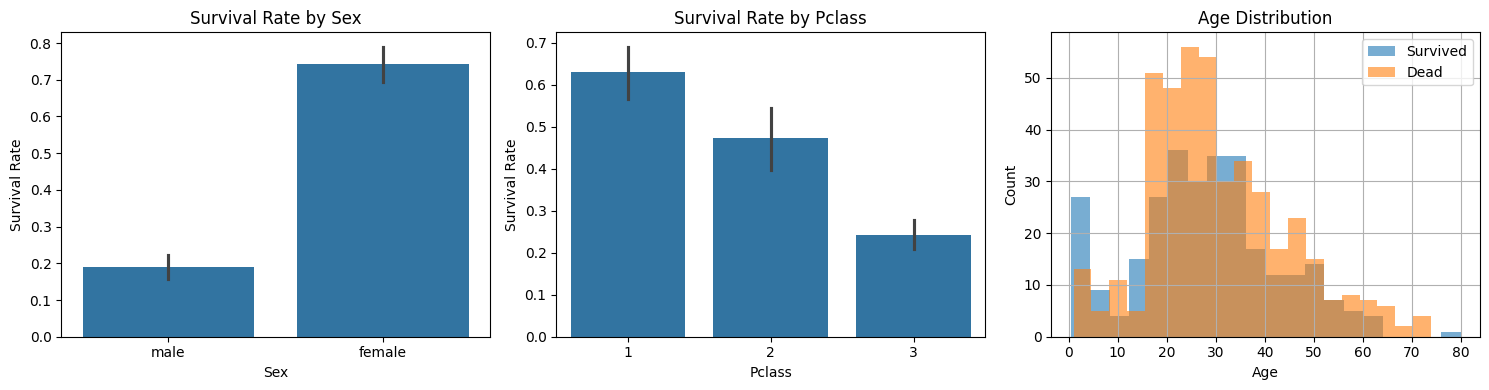

In [3]:
# plt.subplots(1,3)→1行3列のグラフ領域を作る
# fig, axes = →関数が2つの値を返すので2変数で同時に受け取っている
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival rate by Sex
# sns.braplot()→seabornで棒グラフを描く関数
# set_title(...)→グラフのタイトルを設定
sns.barplot(data=train, x='Sex', y='Survived', ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

# Survival rate by Pclass
sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[1])
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')

# Age distribution by Survived
# train["Survived"] == 1で[False, True, True, False, ...] という真偽値の列ができる
# train[train["Survived"] == 1]でTrueの行だけ取り出す
# train[train['Survived'] == 1]['Age']でさらにAge列だけ取り出す

train[train['Survived']==1]['Age'].hist(ax=axes[2], alpha=0.6, label='Survived', bins=20)
train[train['Survived']==0]['Age'].hist(ax=axes[2], alpha=0.6, label='Dead', bins=20)
axes[2].legend()
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')

plt.tight_layout() # グラフ同士が重ならないように
plt.show() # 画面表示

## データの前処理
- `df.copy()`で元の`train`データを壊さないようにコピーを作ってから処理
- 中央値で補完する方が外れ値に強い
- `Embarked`に関しては2件しか欠損がないので最頻値で埋める
- `Cabin`は77%が欠損で使い物にならないため削除
- 敬称には年齢・性別・社会的地位の情報が凝縮されているため、敬称のみを取り出すことが有効
- バージョン1では、`Age`を全員の中央値で補完していたが、バージョン2では敬称ごとの中央値で補完している。
- 大家族すぎると全員が脱出しづらく生存率が下がり、1人だと助けてくれない傾向→`FamilySize`を定義。`SibSp`と`Parch`を足して+1下列を作る。`IsAlone`も同様に`FamilySize`が1か0かを判定する

In [4]:
def preprocess(df):
    df = df.copy()
    
    # 敬称を名前から抽出
    # .str.extract()は文字列から正規表現でパターンを抽出するメソッド
    # r`...`→raw文字列(\をエスケープ文字として扱わない)
    # ([A-Za-z]+)→アルファベット1文字以上
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    # 敬称をまとめる
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    df['Title'] = df['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})
    df['Title'] = df['Title'].fillna(0)
    
    # 家族サイズ
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # 1人かどうか
    # .astype(int)でTrue→1、False→0に変換
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Cabinの有無
    # .notna()はNaNでなければTrue、NaNならFalseを返す
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    
    # Ageの欠損をTitleごとの中央値で補完（より精度が高い）
    for title in [0, 1, 2, 3, 4]:
        mask = (df['Title'] == title) & df['Age'].isna()
        median_age = df.loc[df['Title'] == title, 'Age'].median()
        df.loc[mask, 'Age'] = median_age
    df['Age'] = df['Age'].fillna(df['Age'].median())
    
    # Embarkedの欠損を最頻値で補完
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # Fareの欠損を中央値で補完
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    # 数値変換
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # 不要な列を削除
    df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
    
    return df

train_processed = preprocess(train)
test_processed  = preprocess(test)
print(train_processed.head())
print(train_processed.isnull().sum())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  \
0         0       3    0  22.0      1      0   7.2500         0      0   
1         1       1    1  38.0      1      0  71.2833         1      2   
2         1       3    1  26.0      0      0   7.9250         0      1   
3         1       1    1  35.0      1      0  53.1000         0      2   
4         0       3    0  35.0      0      0   8.0500         0      0   

   FamilySize  IsAlone  HasCabin  
0           2        0         0  
1           2        0         1  
2           1        1         0  
3           2        0         1  
4           1        1         0  
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
HasCabin      0
dtype: int64


## ランダムフォレスト
- `Titanic`のデータはテーブルデータで、特長量が数値・カテゴリ混在
- ランダムフォレストは**非線形な関係も捉えられる**、**欠損や外れ値に強い**といったメリットが挙げられる
- 今回はデータ件数が891件であったため、ニューラルネットより決定木系のランダムフォレストを利用する

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 特徴量とラベルを分離
X = train_processed.drop('Survived', axis=1)
y = train_processed['Survived']

# モデルの定義
# n_estimators=100→決定木を100本作る
# random_state=42→シードを固定して、再現性担保
model = RandomForestClassifier(n_estimators=300, max_depth=7, random_state=42)

# 交差検証でスコア確認
# cv=5→データを5分割して5回検証
# scoring="accuracy"→正解率で評価
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

# 全trainデータでモデルを学習
# 交差検証はあくまでスコア確認用、実際の提出用モデルは全データで学習させた方が精度向上
model.fit(X, y)

# testデータを予測
X_test = test_processed.drop('Survived', axis=1, errors='ignore')
predictions = model.predict(X_test)

print(f'予測完了: {len(predictions)}件')
print(predictions[:10])

CV Accuracy: 0.8260 ± 0.0164
予測完了: 418件
[0 0 0 0 1 0 1 0 1 0]


In [6]:
# 提出ファイルの作成
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})

# csvファイルに変換、インデックスは入れない
submission.to_csv('/kaggle/working/submission.csv', index=False)
print(submission.head(10))
print(f'Shape: {submission.shape}')

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0
Shape: (418, 2)
